# __Глубокое обучение__

## Тема 8.1. Нейронные сети для аппроксимации решений дифференциальных уравнений
 


## Сети PINN для уравнений с частными производными

#### Загрузка пакета для работы с PINN

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from math import *
import tensorflow as tf
import sys

import scipy

tf.keras.backend.set_floatx('float64')
tf.get_logger().setLevel('ERROR')

from pinns import PINNs 

## 1. Введение в простые PINN <a name="1-bullet"></a>

Сначала вспомним общую формулировку простых PINN. Рассмотрим следующее параметризованное уравнение в частных производных, определенное в области $\Omega \subset \mathbb{R}^d$ с границей $\partial\Omega$:

\begin{align}
&\partial_t \boldsymbol{u} + \mathcal{N}_\boldsymbol{\mathrm{x}}(\boldsymbol{u}, \lambda)=0, \text{ for } \boldsymbol{\mathrm{x}}\in\Omega, t\in[0,T]\\
&\boldsymbol{u}(\boldsymbol{\mathrm{x}},0)=g(\boldsymbol{\mathrm{x}}), \text{ for } \boldsymbol{\mathrm{x}}\in\Omega\\
&\mathcal{B}(\boldsymbol{u},\boldsymbol{\mathrm{x}},t)=0, \text{ for } \boldsymbol{\mathrm{x}}\in\partial\Omega\\
\end{align}
где $\boldsymbol{\mathrm{x}} \in \mathbb{R}^d$ и $t$ — пространственные и временные координаты, $\mathcal{N}_{\boldsymbol{\mathrm{x}}}$ — дифференциальный оператор, $\boldsymbol{\lambda}$ — параметр уравнения в частных производных, $\boldsymbol{u}$ — решение уравнения в частных производных с начальным условием $g(\boldsymbol{\mathrm{x}})$ и граничным условием $\mathcal{B}$, которое может быть условиями Дирихле, Неймана, Робина или периодическими граничными условиями. Нижние индексы обозначают частные производные по времени или пространству. В PINN решение $\boldsymbol{u}$ уравнения в частных производных аппроксимируется полносвязной нейронной сетью прямого распространения $\mathcal{NN}$:
\begin{align*}
    \boldsymbol{u} \approx \hat{\boldsymbol{u}} = \mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta})
\end{align*}
где $\hat{\boldsymbol{u}}$ обозначает прогнозируемое значение решения, а $\boldsymbol{\theta}$ обозначает обучаемые параметры нейронной сети. Параметры нейронной сети обучаются путем минимизации функции потерь $L$:
\begin{align}
    L = L_{pde} + L_{ic} + L_{bc} + L_{data}
\end{align}
где члены $L_{pde},L_{ic},L_{bc}$ и $L_{data}$ штрафуют потери в невязке PDE, начального условия, граничного условия и контролируемых данных (измерений) соответственно, что можно представить следующим образом:
\begin{align*}
    L_{pde} &= \dfrac{1}{N_{pde}}\sum_{i=1}^{N_{pde}}|\hat{\boldsymbol{u}}_{t^i} + \mathcal{N}_{\boldsymbol{\mathrm{x}}^{i}}(\hat{\boldsymbol{u}^{i}}, \boldsymbol{\lambda})|^2\\
    L_{ic} &= \dfrac{w_{ic}}{N_{ic}}\sum_{i=1}^{N_{ic}}|\boldsymbol{\hat{u}}(\boldsymbol{\mathrm{x}}^i,0) - g(\boldsymbol{\mathrm{x}}^i)|^2\\
    L_{bc} &= \dfrac{w_{bc}}{N_{bc}}\sum_{i=1}^{N_{bc}}|\mathcal{B}(\hat{\boldsymbol{u}^i}, \boldsymbol{\mathrm{x}}^{i}, t^{i})|^2\\
    L_{data} &= \dfrac{w_{data}}{N_{data}}\sum_{i=1}^{N_{data}}|\hat{\boldsymbol{u}}(\boldsymbol{\mathrm{x}}^i,t^i) - \boldsymbol{u}(\boldsymbol{\mathrm{x}}^i,t^i)|^2\\
\end{align*}
где $w_{ic}, w_{bc}, w_{data}$ — веса для балансировки различных членов в функции потерь.

Определение функции потерь $L$ и обучаемых параметров зависит от задач:
|Тип задачи | Вход $\mathcal{NN}$ | Обучаемые параметры | Функция потерь |
| :- | -: | -: |-: |
| Прямая | $(\boldsymbol{\mathrm{x}},t)$ | $\theta$ | $L = L_{pde} + L_{ic} + L_{bc}$
| Обратная | $(\boldsymbol{\mathrm{x}},t)$ | $\theta,\lambda$ | $L = L_{pde} + L_{data}$
| Некорректная | $(\boldsymbol{\mathrm{x}},t)$ | $\theta$ | $L = L_{pde} + L_{data}$
| Обобщение | $(\boldsymbol{\mathrm{x}},t,\lambda)$ | $\theta$ | $L = L_{pde} + L_{ic} + L_{bc}$


## Прямая задача

В прямых задачах начальные и/или граничные условия (IC и/или BC) уравнений в частных производных четко определены. Измерения решения (контролируемые данные) в каких-либо точках не обязательны. Требуется найти  решение во всей области с помощью сети PINN.

Для решения задачи уравнения в частных производных существуют две эквивалентные формулировки: сильная форма и слабая форма.
* Сильная форма состоит из дифференциальных уравнений вместе с IC и BC. Она налагает требования непрерывности и дифференцируемости на потенциальные решения уравнения.
* Слабая форма — это альтернативное представление дифференциальных уравнений, которое ослабляет требования непрерывности и дифференцируемости. Она уменьшает порядок производных и заставляет решение удовлетворять интегральным функциям.

### Пример: вязкое уравнение Бюргерса <a name="1.1-bullet"></a>
Рассматриваем следующее вязкое уравнение Бюргерса:

\begin{align}
  &u_t + uu_x -\nu u_{xx} = 0 \quad \text{для } x\in [-1,1], t\in[0, 1] \\
  &u(x,0) = -\sin(\pi x) \quad \text{для } x\in [-1,1]\\
  &u(-1,t) = u(1,t) = 0 \quad \text{для } t\in [0,1]
\end{align}
где $\nu$ — параметр уравнения. Примем, что $\nu=0.025$.

Обозначим через $\hat{u}=\mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta})$ предсказание сети PINN для решения. Функция потерь, которая включает потери IC/BC и невязку уравнения, теперь становится равной:
\begin{align}
  L &= L_{pde} + L_{ic} + L_{bc}\\
    &= \dfrac{1}{N_{pde}}\sum_{i=1}^{N_{pde}}|\hat{u}^i_{t} + \hat{u}^i\hat{u}^i_{x}-\nu \hat{u}_{xx}|^2 + \dfrac{w_{ic}}{N_{ic}}\sum_{i=1}^{N_{ic}}|\hat{u}(x^i,0) + \sin(\pi x^i)|^2 + \dfrac{w_{bc}}{N_{bc}}\sum_{i=1}^{N_{bc}}(|\hat{u}(-1,t^i)|^2+|\hat{u}(1,t^i)|^2)
\end{align}
Допустим, что $w_{ic}=w_{bc}=1$.

Предпримем следующие шаги для построения и обучения сети PINN:
* Определим область
* Определим начальные/граничные условия (IC/BC) и точки обучения
* Определим невязку и член потерь для уравнения (PDE)
* Определим архитектуру сети PINN
* Обучим сеть PINN

#### Определение области

In [2]:
# определяем область

nx = 256
nt = 100
x = np.linspace(-1, 1, nx)
t = np.linspace(0, 1, nt)
X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

#### Определение начальных/граничных (IC/BC) условий, точек обучения и параметров PDE

In [3]:
# определяем начальные условия IC
idx_init = np.where(X_star[:, 1]==0)[0]
X_init = X_star[idx_init]
u_init = -np.sin(pi*X_init[:, 0:1])

# определяем граничные условия BC
idx_bc = np.where((X_star[:, 0]==1.0)|(X_star[:, 0]==-1.0))[0]
X_bc = X_star[idx_bc]
u_bc = np.zeros((X_bc.shape[0], 1))

# определяем обучающие точки (точки коллокации)
N_f = 2000
idx_Xf = np.random.choice(X_star.shape[0], N_f, replace=False)
X_colloc_train = X_star[idx_Xf]

# определяем параметр PDE
nu = 0.025

__Метод коллокации__ — это метод численного решения дифференциальных уравнений, который состоит в выборе конечномерного пространства возможных решений (обычно полиномов до определенной степени) и ряда точек в области (называемых __точками коллокации__), и выборе того решения, которое удовлетворяет данному уравнению в точках коллокации.

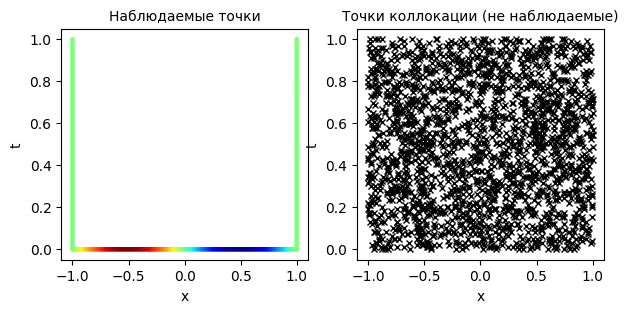

In [4]:
X_supervised = np.concatenate((X_init, X_bc), axis=0)
u_supervised = np.concatenate((u_init, u_bc), axis=0)

fig = plt.figure(figsize=[7,3])
axes = fig.subplots(1,2, sharex=False, sharey=False)
img1 = axes[0].scatter(X_supervised[:, 0:1], X_supervised[:, 1:2], c=u_supervised, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Наблюдаемые точки', fontsize=10)
axes[0].set_xlabel('x', fontsize=10)
axes[0].set_ylabel('t', fontsize=10)
# plt.colorbar(img1, ax=axes[0])
img2 = axes[1].plot(X_colloc_train[:, 0], X_colloc_train[:, 1], 'x', markersize=5, color='black')
axes[1].set_title('Точки коллокации (не наблюдаемые)', fontsize=10)
axes[1].set_xlabel('x', fontsize=10)
axes[1].set_ylabel('t', fontsize=10);

#### Определение невязки PDE и члена потерь для PDE

In [5]:
def net_transform(X_f, model_nn):
    return model_nn(X_f)

def f_user(X_f, model_nn):
    x_temp = X_f[:, 0:1]
    t_temp = X_f[:, 1:2]
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x_temp)
        tape.watch(t_temp)
        X_temp = tf.concat([x_temp, t_temp], axis=1)

        u = net_transform(X_temp, model_nn)

        u_x = tape.gradient(u, x_temp)
        u_xx = tape.gradient(u_x, x_temp)
        u_t = tape.gradient(u, t_temp)

    del tape
    f = u_t + u*u_x - nu*u_xx
    return f

def loss_f(f):
    return tf.reduce_mean(tf.square(f))

#### Определение архитектуры сети PINN

In [6]:
# глубина и ширина нейронной сети
layers = [2] + [50]*4 + [1]

# скорость обучения для оптимизатора Адам
lr = 0.001

#### Обучение сети PINN

Алгоритм Бройдена—Флетчера—Гольдфарба—Шанно (__BFGS__) (Broyden—Fletcher—Goldfarb—Shanno algorithm) — это итерационный метод численной оптимизации, предназначенный для нахождения локального максимума/минимума нелинейного функционала без ограничений.

Алгоритм BFGS — один из наиболее широко применяемых квазиньютоновских методов. В квазиньютоновских методах гессиан функции не вычисляется напрямую. Вместо этого гессиан оценивается приближенно, исходя из сделанных до этого шагов. Также существуют модификация данного метода с ограниченным использованием памяти (L-BFGS), который предназначен для решения нелинейных задач с большим количеством неизвестных, а также модификация с ограниченным использованием памяти в многомерном кубе (L-BFGS-B).

Теоретически алгоритм BFGS находит минимум любой дважды непрерывно дифференцируемой выпуклой функции. Несмотря на эти ограничения, как показывает практика, алгоритм BFGS хорошо справляется и с невыпуклыми функциями.

In [7]:
model_classic = PINNs(
    X_colloc_train, net_transform, f_user, loss_f, layers, lr, type_problem='forward', 
    X_bc = X_bc, u_bc = u_bc, X_init = X_init, u_init = u_init
)

model_classic.train(max_epochs_adam=0, max_epochs_lbfgs=2000, print_per_epochs=100)

2025-12-10 11:30:30.131658: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2025-12-10 11:30:30.131681: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-12-10 11:30:30.131688: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
I0000 00:00:1765355430.131700 3953673 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1765355430.131722 3953673 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


No data inside the domain
No other condition is provided
No data for testing


2025-12-10 11:30:34.206339: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Loss pinns at epoch 0 (L-BFGS): 0.42127081639897823
Loss pinns at epoch 100 (L-BFGS): 0.03735619881914596
Loss pinns at epoch 200 (L-BFGS): 0.006813075469344681
Loss pinns at epoch 300 (L-BFGS): 0.00196903172529674
Loss pinns at epoch 400 (L-BFGS): 0.000664732751699003
Loss pinns at epoch 500 (L-BFGS): 0.0003883488301218389
Loss pinns at epoch 600 (L-BFGS): 0.00022192509912368006
Loss pinns at epoch 700 (L-BFGS): 0.00012730996416510966
Loss pinns at epoch 800 (L-BFGS): 8.432143533847707e-05
Loss pinns at epoch 900 (L-BFGS): 6.199945886128854e-05
Loss pinns at epoch 1000 (L-BFGS): 4.370098895284269e-05
Loss pinns at epoch 1100 (L-BFGS): 3.091108008502862e-05
Loss pinns at epoch 1200 (L-BFGS): 2.2618379018408936e-05
Loss pinns at epoch 1300 (L-BFGS): 1.737705048039533e-05
Loss pinns at epoch 1400 (L-BFGS): 1.3696010094461397e-05
Loss pinns at epoch 1500 (L-BFGS): 1.1306617673764236e-05
Loss pinns at epoch 1600 (L-BFGS): 8.99271109729808e-06
Loss pinns at epoch 1700 (L-BFGS): 8.2169267392

#### Визуализация результатов

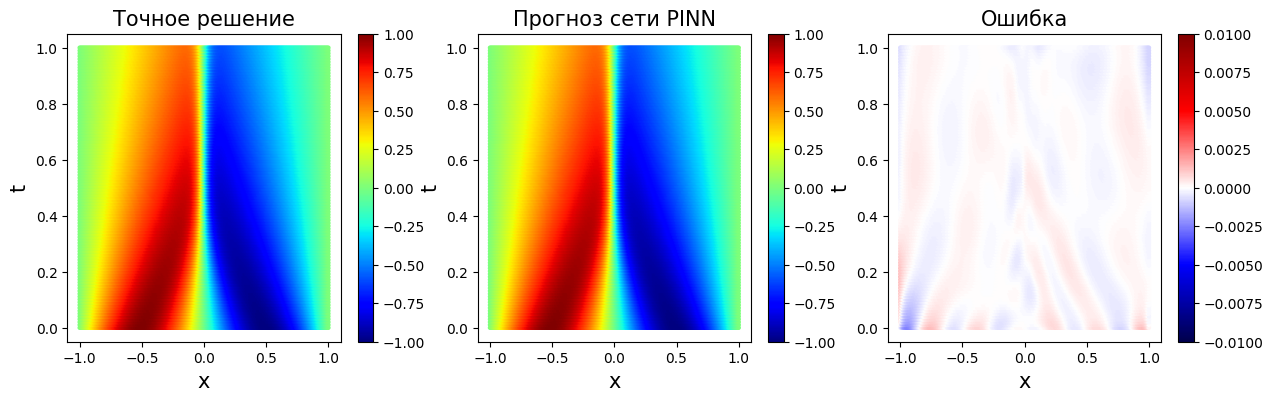

In [8]:
pred = model_classic.net_transform(tf.convert_to_tensor(X_star, dtype='float64'), model_classic.net_u)

u_star_array = np.load('./burgers_sol.npy', allow_pickle=True)
u_star = u_star_array[-1]

fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], c=pred, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз сети PINN', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star-pred, cmap='seismic', vmax=0.01, vmin=-0.01, s=5)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

#### Визуализация функции потерь

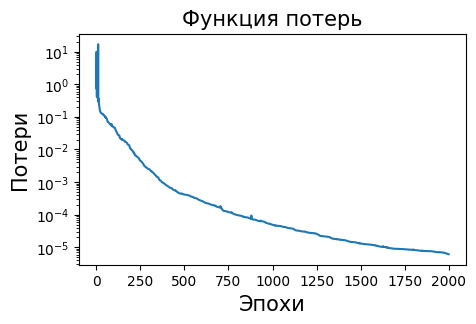

In [9]:
fig = plt.figure(figsize=[5,3])
plt.semilogy(model_classic.loss_array)
plt.xlabel('Эпохи', fontsize=15)
plt.ylabel('Потери', fontsize=15)
plt.title('Функция потерь', fontsize=15);

### Увеличение производительности за счет жестких IC/BC условий 
Вспомним начальные/граничные условия (IC/BC) этой задачи:
\begin{align}
&u(x,0) = -\sin(\pi x) \quad \text{для } x\in [-1,1]\\
&u(-1,t) = u(1,t) = 0 \quad \text{для } t\in [0,1]
\end{align}

Можно обеспечить автоматическое выполнение начальных/граничных условий (IC/BC). Вместо того, чтобы использовать шаблон прогноза $\hat{\boldsymbol{u}} = \mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta})$, можно использовать следующее представление:
$$\hat{\boldsymbol{u}} = t(x-1)(x+1) \mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta}) - \sin(\pi x)$$

Чтобы сделать это, изменим функцию `net_transform()` в сети PINN.

In [10]:
def net_transform(X_f, model_nn):
    x_f = X_f[:, 0:1]
    t_f = X_f[:, 1:2]
    return model_nn(X_f)*t_f*(x_f+1)*(x_f-1) - tf.math.sin(pi*x_f)

#### Обучение сети PINN

In [11]:
model_classic = PINNs(
    X_colloc_train, net_transform, f_user, loss_f, layers, lr, type_problem='forward'
)

model_classic.train(max_epochs_adam=0, max_epochs_lbfgs=2000, print_per_epochs=100)

No data on the boundary
No data at the initial instant
No data inside the domain
No other condition is provided
No data for testing
Loss pinns at epoch 0 (L-BFGS): 0.9818018541619183
Loss pinns at epoch 100 (L-BFGS): 0.129990360877437
Loss pinns at epoch 200 (L-BFGS): 0.053403685769944816
Loss pinns at epoch 300 (L-BFGS): 0.035421884071337444
Loss pinns at epoch 400 (L-BFGS): 0.02212605388650718
Loss pinns at epoch 500 (L-BFGS): 0.016786969293028465
Loss pinns at epoch 600 (L-BFGS): 0.012392910258018506
Loss pinns at epoch 700 (L-BFGS): 0.008768383299645806
Loss pinns at epoch 800 (L-BFGS): 0.006879834892322242
Loss pinns at epoch 900 (L-BFGS): 0.0049814438104213345
Loss pinns at epoch 1000 (L-BFGS): 0.003846168419631497
Loss pinns at epoch 1100 (L-BFGS): 0.003057485321923318
Loss pinns at epoch 1200 (L-BFGS): 0.0025862636435828924
Loss pinns at epoch 1300 (L-BFGS): 0.0021082520547953303
Loss pinns at epoch 1400 (L-BFGS): 0.0016771786972211134
Loss pinns at epoch 1500 (L-BFGS): 0.00125

#### Визуализация результатов

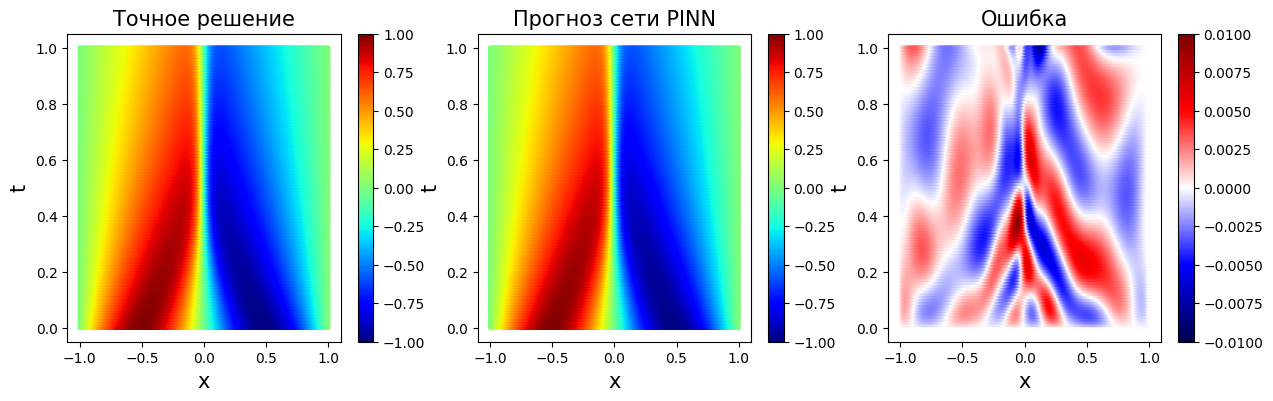

In [12]:
pred = model_classic.net_transform(tf.convert_to_tensor(X_star, dtype='float64'), model_classic.net_u)

fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], c=pred, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз сети PINN', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star-pred, cmap='seismic', vmax=0.01, vmin=-0.01, s=5)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

### Пример: невязкое уравнение Бюргерса <a name="1.2-bullet"></a>

Рассмотрим следующее невязкое уравнение Бюргерса:
\begin{align}
  &u_t + uu_x = 0 \quad \text{for } x\in [-1,1], t\in[0, 1] \\
  &u(x,0) = -\sin(\pi x) \quad \text{for } x\in [-1,1]\\
  &u(-1,t) = u(1,t) = 0 \quad \text{for } t\in [0,1]
\end{align}


In [13]:
# определяем область

nx = 256
nt = 100
x = np.linspace(-1, 1, nx)
t = np.linspace(0, 1, nt)
X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

#### Определение начальных/граничных условий (IC/BC) и точек обучения

In [14]:
# определяем IC
idx_init = np.where(X_star[:, 1]==0)[0]
X_init = X_star[idx_init]
u_init = -np.sin(pi*X_init[:, 0:1])

# определяем BC
idx_bc = np.where((X_star[:, 0]==1.0)|(X_star[:, 0]==-1.0))[0]
X_bc = X_star[idx_bc]
u_bc = np.zeros((X_bc.shape[0], 1))

# определяем точки обучения
N_f = 2000
idx_Xf = np.random.choice(X_star.shape[0], N_f, replace=False)
X_colloc_train = X_star[idx_Xf]

#### Определение невязки PDE и члена потерь для PDE

In [15]:
def net_transform(X_f, model_nn):
    return model_nn(X_f)

def f_user(X_f, model_nn):
    x_temp = X_f[:, 0:1]
    t_temp = X_f[:, 1:2]
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x_temp)
        tape.watch(t_temp)
        X_temp = tf.concat([x_temp, t_temp], axis=1)

        u = net_transform(X_temp, model_nn)

        u_x = tape.gradient(u, x_temp)
        u_t = tape.gradient(u, t_temp)

    f = u_t + u * u_x
    return f

def loss_f(f):
    return tf.reduce_mean(tf.square(f))

#### Определение архитектуры сети PINN

In [16]:
# глубина и ширина нейронной сети
layers = [2] + [50]*4 + [1]

# скорость обучения для оптимизатора
lr = 0.001

#### Обучение сети PINN

In [17]:
model_classic = PINNs(
    X_colloc_train, net_transform, f_user, loss_f, layers, lr, type_problem='forward', 
    X_bc = X_bc, u_bc = u_bc, X_init = X_init, u_init = u_init
)

model_classic.train(max_epochs_adam=0, max_epochs_lbfgs=2000, print_per_epochs=200)

No data inside the domain
No other condition is provided
No data for testing
Loss pinns at epoch 0 (L-BFGS): 0.4191019646121363
Loss pinns at epoch 200 (L-BFGS): 0.09570225875045806
Loss pinns at epoch 400 (L-BFGS): 0.07573154417876764
Loss pinns at epoch 600 (L-BFGS): 0.07260540072106215
Loss pinns at epoch 800 (L-BFGS): 0.07076129350233622
Loss pinns at epoch 1000 (L-BFGS): 0.06894956339801148
Loss pinns at epoch 1200 (L-BFGS): 0.062738877599338
Loss pinns at epoch 1400 (L-BFGS): 0.05931327114945896
Loss pinns at epoch 1600 (L-BFGS): 0.05699903849874944


#### Визуализация результатов

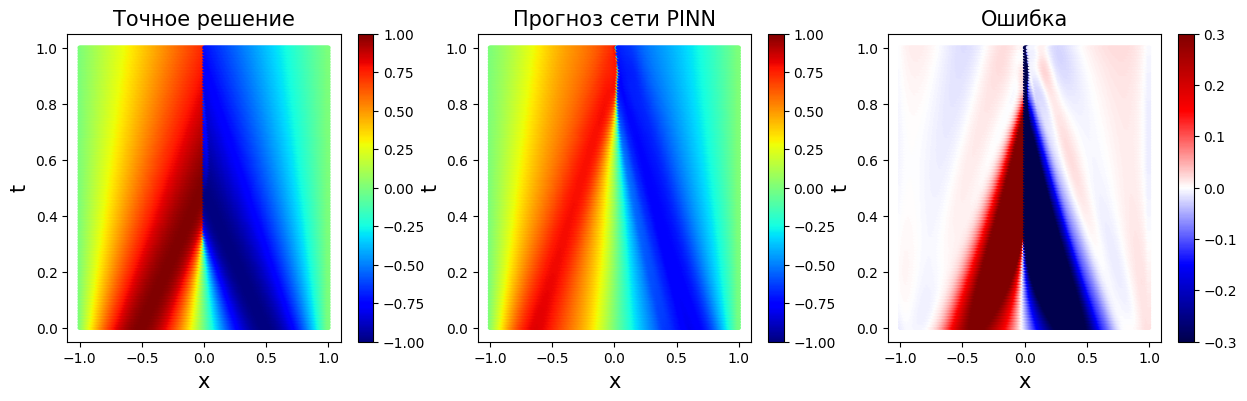

In [18]:
pred = model_classic.net_transform(tf.convert_to_tensor(X_star, dtype='float64'), model_classic.net_u)

u_star_array = np.load('./burgers_sol.npy', allow_pickle=True)
u_star = u_star_array[1]

fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], c=pred, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз сети PINN', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star-pred, cmap='seismic', vmax=0.3, vmin=-0.3, s=5)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

### Увеличение производительности за счет жестких IC/BC условий

Как и прежде, используем шаблон:
$$\hat{\boldsymbol{u}} = t(x-1)(x+1) \mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta}) - \sin(\pi x)$$

Для этого модифицируем функцию `net_transform()` сети PINN.

In [19]:
def net_transform(X_f, model_nn):
    return model_nn(X_f)*X_f[:, 1:2]*(X_f[:, 0:1]+1)*(X_f[:, 0:1]-1) - tf.math.sin(pi*X_f[:, 0:1])

#### Обучение сети PINN

In [20]:
model_classic = PINNs(
    X_colloc_train, net_transform, f_user, loss_f, layers, lr, type_problem='forward'
)

model_classic.train(max_epochs_adam=0, max_epochs_lbfgs=2000, print_per_epochs=100)

No data on the boundary
No data at the initial instant
No data inside the domain
No other condition is provided
No data for testing
Loss pinns at epoch 0 (L-BFGS): 0.9936279079429547
Loss pinns at epoch 100 (L-BFGS): 0.2979813309487067
Loss pinns at epoch 200 (L-BFGS): 0.24237884302734722
Loss pinns at epoch 300 (L-BFGS): 0.11004187713642057
Loss pinns at epoch 400 (L-BFGS): 0.049736827259127404
Loss pinns at epoch 500 (L-BFGS): 0.031717165308687276
Loss pinns at epoch 600 (L-BFGS): 0.02358767840095534
Loss pinns at epoch 700 (L-BFGS): 0.01878063639188866
Loss pinns at epoch 800 (L-BFGS): 0.014996449639891104
Loss pinns at epoch 900 (L-BFGS): 0.012986560791518872
Loss pinns at epoch 1000 (L-BFGS): 0.011604959443959811
Loss pinns at epoch 1100 (L-BFGS): 0.01059804575465712
Loss pinns at epoch 1200 (L-BFGS): 0.009711113906139242
Loss pinns at epoch 1300 (L-BFGS): 0.009015729291198687
Loss pinns at epoch 1400 (L-BFGS): 0.00825646754069669
Loss pinns at epoch 1500 (L-BFGS): 0.0075717105756

#### Визуализация результатов

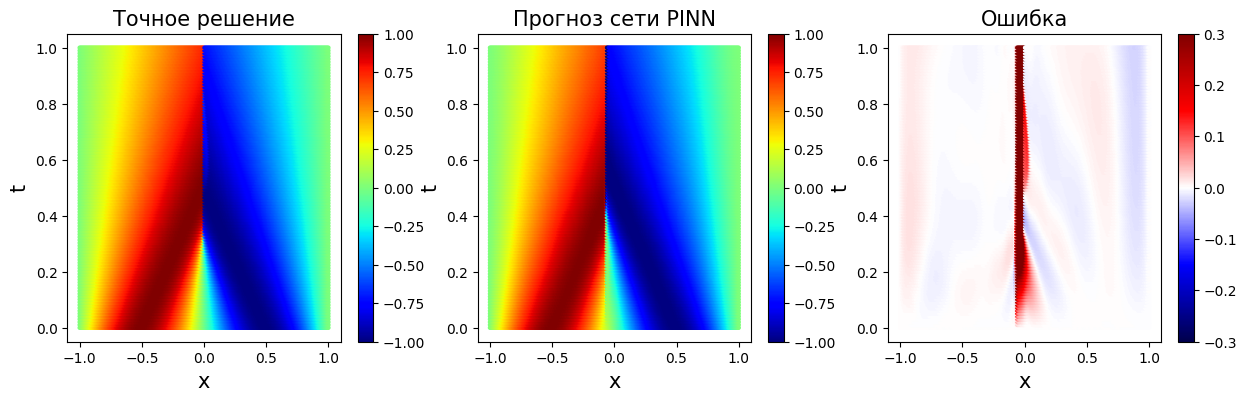

In [21]:
pred = model_classic.net_transform(tf.convert_to_tensor(X_star, dtype='float64'), model_classic.net_u)

u_star_array = np.load('./burgers_sol.npy', allow_pickle=True)
u_star = u_star_array[1]

fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], c=pred, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз сети PINN', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star-pred, cmap='seismic', vmax=0.3, vmin=-0.3, s=5)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

### Пример: увеличение точек коллокации для повышения качества

In [22]:
# определим точки обучения
N_f = 10000
idx_Xf = np.random.choice(X_star.shape[0], N_f, replace=False)
X_colloc_train = X_star[idx_Xf]

#### Обучение сети PINN

In [23]:
model_classic = PINNs(
    X_colloc_train, net_transform, f_user, loss_f, layers, lr, type_problem='forward'
)

model_classic.train(max_epochs_adam=0, max_epochs_lbfgs=2500, print_per_epochs=250)

No data on the boundary
No data at the initial instant
No data inside the domain
No other condition is provided
No data for testing
Loss pinns at epoch 0 (L-BFGS): 0.6500561695015491
Loss pinns at epoch 250 (L-BFGS): 0.26118345221205147
Loss pinns at epoch 500 (L-BFGS): 0.24627680358506915
Loss pinns at epoch 750 (L-BFGS): 0.2355533051632381
Loss pinns at epoch 1000 (L-BFGS): 0.22773001263355094
Loss pinns at epoch 1250 (L-BFGS): 0.22254669525227072
Loss pinns at epoch 1500 (L-BFGS): 0.21097937894427082
Loss pinns at epoch 1750 (L-BFGS): 0.20215470551000247
Loss pinns at epoch 2000 (L-BFGS): 0.19490037118364387
Loss pinns at epoch 2250 (L-BFGS): 0.18920657895166168


#### Визуализация результатов

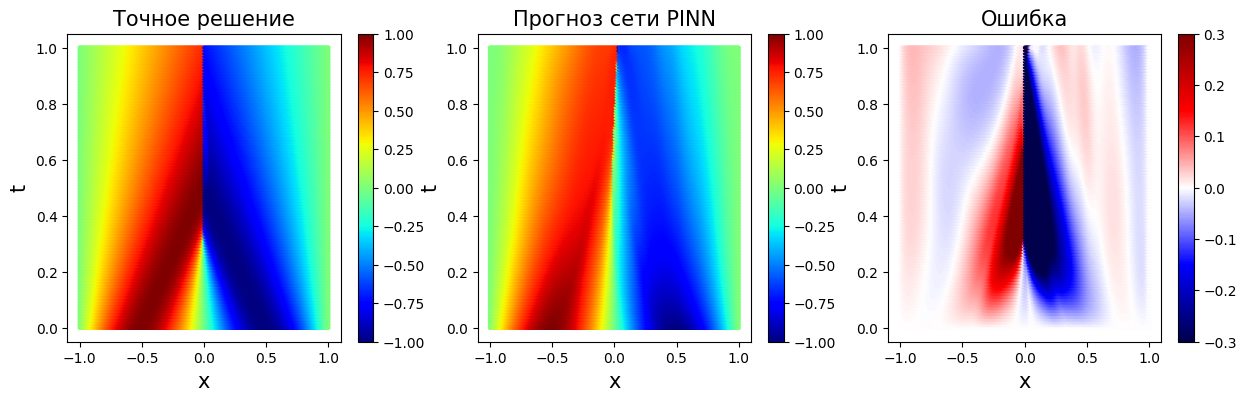

In [24]:
pred = model_classic.net_transform(tf.convert_to_tensor(X_star, dtype='float64'), model_classic.net_u)

fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], c=pred, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз сети PINN', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(X_star[:, 0:1], X_star[:, 1:2], c=u_star-pred, cmap='seismic', vmax=0.3, vmin=-0.3, s=5)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

## 2. Обратная задача <a name="2-bullet"></a>

В обратных задачах доступны измерения решений в некоторых точках (контролируемые данные), однако параметры уравнения неизвестны. Требуется определить эти параметры с помощью сети PINN.

### 2.1. Пример: уравнение Бюргерса <a name="2.1-bullet"></a>
И снова, для иллюстрации, рассмотрим следующее уравнение Бюргерса:
\begin{align}
&u_t + \nu_1uu_x -\nu_2 u_{xx} = 0 \quad \text{для } x\in [-1,1], t\in[0, 1] \\
&u(x,0) = -\sin(\pi x) \quad \text{для } x\in [-1,1]\\
&u(-1,t) = u(1,t) = 0 \quad \text{для } t\in [0,1]
\end{align}
где $\boldsymbol{\nu} = (\nu_1,\nu_2)$ — неизвестные параметры уравнения в частных производных.

Здесь предполагается, что контролируемые данные доступны и распределены случайным образом в области с $N_{data}=2000$. Поскольку параметры уравнения неизвестны, будем рассматривать их как параметры обучения нейронной сети.

Обозначим через $\hat{u}=\mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta}, \boldsymbol{\nu})$ прогноз сети PINN для решения. Функция потерь, которая включает потери для данных и для невязки PDE, теперь становится равной:
\begin{align}
L &= L_{pde} +L_{data}\\
&= \dfrac{1}{N_{pde}}\sum_{i=1}^{N_{pde}}|\hat{u}^i_{t} + \nu_1\hat{u}^i\hat{u}^i_{x} -\nu_2 \hat{u}^i_{xx}|^2 + \dfrac{w_{data}}{N_{data}}\sum_{i=1}^{N_{data}}|\hat{u}(x^i,t^i) - u(x^i,t^i)|^2
\end{align}
Здесь коэффициент $w_{data}=1$.

#### Определение области и точного решения

In [25]:
# определяем область

nx = 256
nt = 100
x = np.linspace(-1, 1, nx)
t = np.linspace(0, 1, nt)
X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

# точное решение
u_star_array = np.load('./burgers_sol.npy', allow_pickle=True)
u_star = u_star_array[-1]

# истинные значения параметров уравнения
nu_1_true = 1
nu_2_true = 0.025

#### Определение точек обучения

In [26]:
# определяем контролируемые точки обучения
N_data = 2000
idx_data = np.random.choice(X_star.shape[0], N_data, replace=False)
X_data = X_star[idx_data]
u_data = u_star[idx_data]

# точки коллокации совпадают с точками обучения
X_colloc_train = X_data

# присваиваем начальные значения параметрам уравнения
nu_1_init = 10
nu_2_init = 1
param_pde_init = np.array([nu_1_init, nu_2_init])

#### Определение невязки PDE и члена потерь для PDE

In [27]:
def net_transform(X_f, model_nn):
    return model_nn(X_f)*X_f[:, 1:2] * (X_f[:, 0:1] + 1) * (X_f[:, 0:1] - 1) - tf.math.sin(pi * X_f[:, 0:1])

def f_user(X_f, model_nn, param_pde):
    x_temp = X_f[:, 0:1]
    t_temp = X_f[:, 1:2]
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x_temp)
        tape.watch(t_temp)
        X_temp = tf.concat([x_temp, t_temp], axis=1)

        u = net_transform(X_temp, model_nn)

        u_x = tape.gradient(u, x_temp)
        u_xx = tape.gradient(u_x, x_temp)
        u_t = tape.gradient(u, t_temp)

    f = u_t + param_pde[0]*u * u_x - param_pde[1] * u_xx
    return f

def loss_f(f):
    return tf.reduce_mean(tf.square(f))

#### Определение архитектуры сети PINN

In [28]:
# глубина и ширина нейронной сети
layers = [2] + [50]*4 + [1]

# скорость обучения для оптимизатора
lr = 0.001

#### Обучение сети PINN

In [29]:
model_classic = PINNs(
    X_colloc_train, net_transform, f_user, loss_f, layers, lr, 
    param_pde=param_pde_init, type_problem='inverse', X_data=X_data, u_data=u_data
)

model_classic.train(max_epochs_adam=0, max_epochs_lbfgs=2000, print_per_epochs=200)

No data on the boundary
No data at the initial instant
No other condition is provided
No data for testing
Loss pinns at epoch 0 (L-BFGS): 89.5477405301092
Loss pinns at epoch 200 (L-BFGS): 0.010054310252803737
Loss pinns at epoch 400 (L-BFGS): 0.003004016288362387
Loss pinns at epoch 600 (L-BFGS): 0.0009959052482309198
Loss pinns at epoch 800 (L-BFGS): 0.00045172193863922427
Loss pinns at epoch 1000 (L-BFGS): 0.00023434855931967144
Loss pinns at epoch 1200 (L-BFGS): 0.00017772732440850958
Loss pinns at epoch 1400 (L-BFGS): 0.0001342023260499254
Loss pinns at epoch 1600 (L-BFGS): 0.00010272829115236236
Loss pinns at epoch 1800 (L-BFGS): 7.42233866314858e-05


#### Визуализация результатов

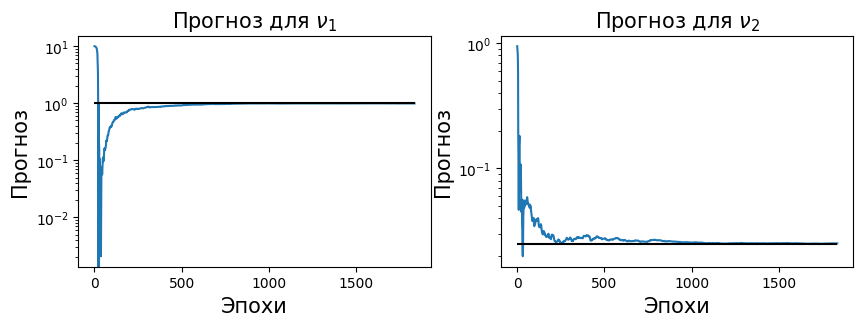

In [30]:
fig = plt.figure(figsize=[10,3])
axes = fig.subplots(1,2, sharex=False, sharey=False)

axes[0].semilogy(model_classic.param_pde_array[0::2])
axes[0].hlines(nu_1_true, xmin=0, xmax=model_classic.epoch, color='black')
axes[0].set_title(r'Прогноз для $\nu_1$', fontsize=15)
axes[0].set_xlabel('Эпохи', fontsize=15)
axes[0].set_ylabel('Прогноз', fontsize=15)

axes[1].semilogy(model_classic.param_pde_array[1::2])
axes[1].hlines(nu_2_true, xmin=0, xmax=model_classic.epoch, color='black')
axes[1].set_title(r'Прогноз для $\nu_2$', fontsize=15)
axes[1].set_xlabel('Эпохи', fontsize=15)
axes[1].set_ylabel('Прогноз', fontsize=15);

#### Визуализация функции потерь

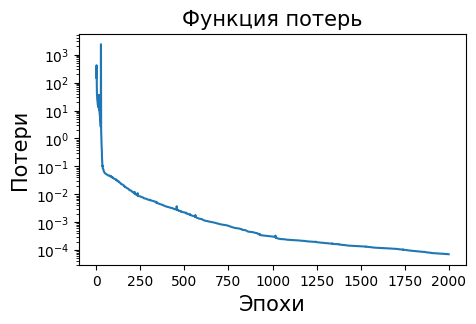

In [31]:
fig = plt.figure(figsize=[5,3])
plt.semilogy(model_classic.loss_array)
plt.xlabel('Эпохи', fontsize=15)
plt.ylabel('Потери', fontsize=15)
plt.title('Функция потерь', fontsize=15);

### 2.2. Пример: линейная упругость <a name="2.2-bullet"></a>

Рассматривается линейная задача упругости, в которой известно решение (смещение). Однако параметры материала, а именно, модуль Юнга и коэффициент Пуассона, неизвестны. Требуется идентифицировать эти параметры, что эквивалентно идентификации констант Ламе.

Рассмотрим квадрат с длиной стороны $L=1$. Объект подчиняется граничным условиям, изображенным на рисунке ниже:

<img src='https://raw.githubusercontent.com/nguyenkhoa0209/pinns_tutorial/main/image/config_linear_elasiticity_square.png' width="700" height="400">

где $(u,v)$ обозначает вектор смещения ($u$ для горизонтальной составляющей и $v$ для вертикальной составляющей).

Предполагается, что решение известно (или доступны измерения/контролируемые точки), и рассчитывается следующим образом:
\begin{align}
u &= \cos(2\pi x)\sin(\pi y)\\
v &= y^4\sin(\pi x)
\end{align}

Однако параметры материала модуль Юнга $E$ и коэффициент Пуассона $\nu$ неизвестны.

Определяющее уравнение в частных производных для линейной эластичности имеет вид:
\begin{align}
&-(\lambda+\mu)\nabla (\nabla \boldsymbol{\vec{u}}) - \mu\nabla^2\boldsymbol{\vec{u}}=\boldsymbol{\vec{f}}\\
\Leftrightarrow&\begin{cases}
(\lambda + \mu)(u_{xx}+v_{xy}) + \mu(u_{xx}+u_{yy})+f_x=0\\
(\lambda + \mu)(u_{xy}+v_{yy}) + \mu(v_{xx}+v_{yy})+f_y=0
\end{cases}
\end{align}
где $\boldsymbol{\vec{f}}=(f_x, f_y)$ — сила, а $\lambda$ и $\mu$ — константы Ламе, которые определяются как:
$$\lambda=\dfrac{E\nu}{(1+\nu)(1-2\nu)} \quad \quad \mu=\dfrac{E}{2(1+\nu)}$$

Таким образом, идентификацию $E$ и $\nu$ можно отождествить с идентификацией констант $\lambda$ и $\mu$.

Будем использовать сеть PINN для идентификации значений $\lambda$ и $\mu$.

#### Определение области и решения

In [32]:
# определение области
L = 1.0
x = np.linspace(0, L, 100).reshape(-1, 1)
y = np.linspace(0, L, 100).reshape(-1, 1)

X,Y = np.meshgrid(x,y)
X_star = np.concatenate((X.flatten().reshape(-1,1), Y.flatten().reshape(-1,1)), axis=1)

# определение решения
u_star = np.cos(2*pi*X_star[:, 0:1])*np.sin(pi*X_star[:, 1:2])
v_star = X_star[:, 1:2]**4*np.sin(pi*X_star[:, 0:1])

U_star = np.concatenate((u_star, v_star), axis=1)

# истинные значения параметров PDE
lbda_true = 1
mu_true = 0.5

#### Определение точек обучения

Чтобы уменьшить вычислительные затраты, предположим, что для решения задачи доступно только $N_{data}=2000$ измерений.

In [33]:
# определение наблюдаемых точек обучения
N_data = 2000
idx_data = np.random.choice(X_star.shape[0], N_data, replace=False)
X_data = X_star[idx_data]
U_data = U_star[idx_data]

# точки коллокации – это наблюдаемые точки
X_colloc_train = X_data

# инициализируем неизвестные параметры
lbda_init = 2
mu_init = 2
param_pde_init = np.array([lbda_init, mu_init])

#### Определение невязки PDE и члена потерь для PDE

In [34]:
def net_transform(X_f, model_nn):
    u = model_nn(X_f)[:, 0:1]#* X_f[:, 1:2]*(1-X_f[:, 1:2]) ## по желанию
    v = model_nn(X_f)[:, 1:2]#* X_f[:, 0:1]*(1-X_f[:, 0:1])* X_f[:, 1:2] ## по желанию
    return tf.concat([u, v], axis=1)

def f_user(X_f, model_nn, param_pde):
    x_temp = X_f[:, 0:1]
    y_temp = X_f[:, 1:2]

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x_temp)
        tape.watch(y_temp)
        X_temp = tf.concat([x_temp, y_temp], axis=1)

        pred = net_transform(X_temp, model_nn)
        u = pred[:, 0:1]
        v = pred[:, 1:2]

        u_x = tape.gradient(u, x_temp)
        u_y = tape.gradient(u, y_temp)
        v_x = tape.gradient(v, x_temp)
        v_y = tape.gradient(v, y_temp)

        u_xx = tape.gradient(u_x, x_temp)
        u_xy = tape.gradient(u_x, y_temp)
        u_yy = tape.gradient(u_y, y_temp)

        v_xx = tape.gradient(v_x, x_temp)
        v_xy = tape.gradient(v_x, y_temp)
        v_yy = tape.gradient(v_y, y_temp)
        
    del tape
    x = x_temp
    y = y_temp

    f_body_x = 17/2*pi**2*tf.math.cos(2*pi*x)*tf.math.sin(pi*y)-6*pi*tf.math.cos(pi*x)*y**3
    f_body_y = -24*tf.math.sin(pi*x)*y**2 + 3*pi**2*tf.math.sin(2*pi*x)*tf.math.cos(pi*y)+0.5*pi**2*y**4*tf.math.sin(pi*x)

    f_x = (param_pde[0]+param_pde[1])*(u_xx+v_xy) + param_pde[1]*(u_xx+u_yy) + f_body_x
    f_y = (param_pde[0]+param_pde[1])*(u_xy+v_yy) + param_pde[1]*(v_xx+v_yy) + f_body_y

    return f_x, f_y

def loss_f(f):
    return tf.reduce_mean(tf.square(f[0])) + tf.reduce_mean(tf.square(f[1]))

#### Определение архитектуры сети PINN

In [35]:
# глубина и ширина нейронной сети
layers = [2] + [50]*4 + [2]

# скорость обучения оптимизатора
lr = 0.001

#### Обучение сети PINN

In [36]:
model_classic = PINNs(
    X_colloc_train, net_transform, f_user, loss_f, layers, lr, 
    param_pde = param_pde_init, type_problem='inverse', X_data = X_data, u_data = U_data
)

model_classic.train(max_epochs_adam=0, max_epochs_lbfgs=5000, print_per_epochs=500)

No data on the boundary
No data at the initial instant
No other condition is provided
No data for testing
Loss pinns at epoch 0 (L-BFGS): 2012.9715665388396
Loss pinns at epoch 500 (L-BFGS): 0.1627130908119158
Loss pinns at epoch 1000 (L-BFGS): 0.13071514262965123
Loss pinns at epoch 1500 (L-BFGS): 0.09520589689921341
Loss pinns at epoch 2000 (L-BFGS): 0.01964721285443496
Loss pinns at epoch 2500 (L-BFGS): 0.007505691356364556
Loss pinns at epoch 3000 (L-BFGS): 0.0037748746483276087
Loss pinns at epoch 3500 (L-BFGS): 0.0021541372291460923
Loss pinns at epoch 4000 (L-BFGS): 0.0012966416526492043
Loss pinns at epoch 4500 (L-BFGS): 0.0008640299082714075


### Визуализация результатов

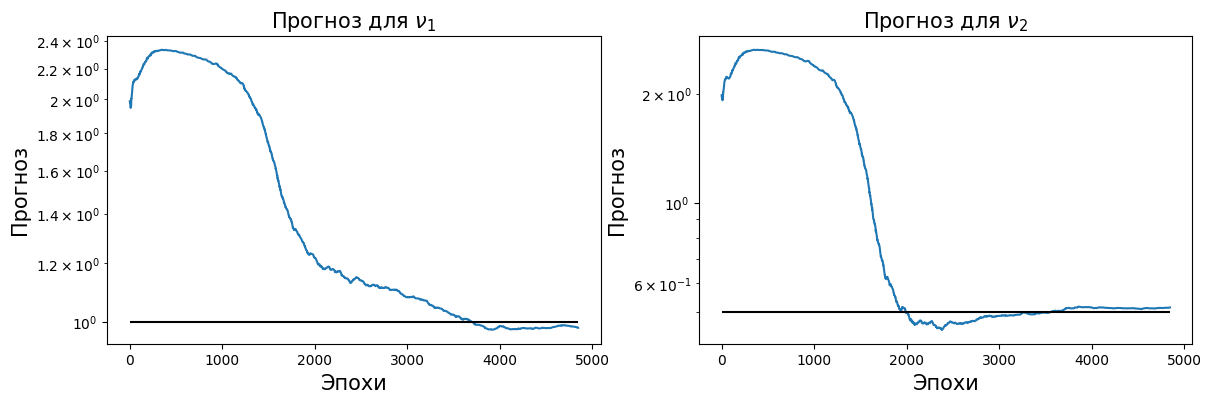

In [37]:
fig = plt.figure(figsize=[14,4])
axes = fig.subplots(1,2, sharex=False, sharey=False)

axes[0].semilogy(model_classic.param_pde_array[0::2])
axes[0].hlines(lbda_true, xmin=0, xmax=model_classic.epoch, color='black')
axes[0].set_title(r'Прогноз для $\nu_1$', fontsize=15)
axes[0].set_xlabel('Эпохи', fontsize=15)
axes[0].set_ylabel('Прогноз', fontsize=15)

axes[1].semilogy(model_classic.param_pde_array[1::2])
axes[1].hlines(mu_true, xmin=0, xmax=model_classic.epoch, color='black')
axes[1].set_title(r'Прогноз для $\nu_2$', fontsize=15)
axes[1].set_xlabel('Эпохи', fontsize=15)
axes[1].set_ylabel('Прогноз', fontsize=15);

## Задание

В задании на ЛР в ТУИС приводятся 10 обыкновенных дифференциальных уравнений (ОДУ) с начальными условиями, пронумерованных от 0 до 9, и их точные решения. В соответствии c последней цифрой номера Вашего студенческого билета выберите ОДУ с начальным условием и выполните следующее задание:

* Постройте и обучите нейронную сеть PINN, аппроксимирующую точное решение ОДУ с начальным условием
* Визуализируйте кривую обучения (эволюцию потерь в ходе обучения) нейронной сети PINN
* Оцените отклонение полученной аппроксимации от точного решения по метрикам MAPE и MSPE
* Визуализируйте точное решение ОДУ и его нейросетевую аппроксимацию